<div style="display: flex; align-items: center;">
    <h1>Batched phenology simulation with <code>diffWOFOST</code></h1>
    <img src="https://raw.githubusercontent.com/WUR-AI/diffWOFOST/refs/heads/main/docs/logo/diffwofost.png" width="150" style="margin-left: 20px;">
</div>

This notebook re-implements the simulation of phenology illustrated in [this notebook](https://github.com/artofmodelling/phenomodelling/blob/main/phenology_modelling.ipynb) with diffWOFOST using a batched approach that allows to run simulations for different locations simultaneously (i.e. within a single engine run). 

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import xarray as xr
from pcse.input import YAMLCropDataProvider
from pcse.util import wind10to2
from diffwofost.physical_models.config import Configuration
from diffwofost.physical_models.crop.phenology import DVS_Phenology
from diffwofost.physical_models.engine import Engine
from diffwofost.physical_models.weather import to_weather_data_iterator

We first clone the repository hosting the phenomodelling notebook, as it includes the required input data as well:

In [2]:
!if [ ! -d phenomodelling ] ; then git clone https://github.com/artofmodelling/phenomodelling.git ; fi

Let's load the phenological observations:

In [3]:
def load_observations():
    """Load observation data."""
    df = pd.read_excel("phenomodelling/data/pheno_obs_1784.xlsx", sheet_name="data")
    return df[df.VALID]

In [4]:
observations = load_observations()

In [5]:
observations.head()

,ObjectID,Longitude,Latitude,DOS,DOA,DOM,DOH,VALID
0,Spring Barley_2010_-0.7_53.87_86565,-0.700067,53.869820,2010-03-19,NaT,2010-08-19,2010-10-15,True
1,Spring Barley_2010_-2.588_55.51_86548,-2.587734,55.510104,2010-04-12,NaT,2010-08-18,NaT,True
2,Spring Barley_2011_-2.988_52.28_89360,-2.988059,52.279508,2011-03-22,2011-06-16,2011-08-21,2011-08-23,True
3,Spring Barley_2011_-3.144_55.727_86748,-3.143778,55.726719,2011-04-18,2011-07-23,NaT,NaT,True
5,Spring Barley_2012_-3.046_55.919_86978,-3.046074,55.919286,2012-03-02,NaT,2012-08-27,NaT,True


We then load the weather data corresponding to the observations:

In [6]:
variable_renaming = [
    ("temperature_max", "TMAX", None),
    ("temperature_min", "TMIN", None),
    ("temperature_avg", "TEMP", None),
    ("vapourpressure", "VAP", None),
    ("windspeed", "WIND", wind10to2),
    ("precipitation", "RAIN", lambda x: x / 10.0),
    ("radiation", "IRRAD", lambda x: x * 1000.0),
    ("snowdepth", "SNOWDEPTH", None),
    ("day", "DAY", None),
]


def load_weather_data_file(object_id):
    """Load weather data for a given location from the corresponding JSON file."""
    with open(f"phenomodelling/data/meteo/{object_id}.json") as f:
        d = json.load(f)

    data = d["data"]

    df = pd.DataFrame(data["weather_variables"])

    # Parse location information
    location_info = data["location_info"]
    lon = float(location_info["grid_agera5_longitude"])
    lat = float(location_info["grid_agera5_latitude"])
    elev = float(location_info["grid_agera5_elevation"])

    # Rename columns and apply unit corrections
    rename_cols = {old_name: new_name for old_name, new_name, _ in variable_renaming}
    convert_cols = {
        new_name: conversion
        for _, new_name, conversion in variable_renaming
        if conversion is not None
    }
    df = df.rename(columns=rename_cols)
    for column, conv in convert_cols.items():
        df[column] = df[column].apply(conv)

    df.DAY = pd.to_datetime(df.DAY)
    return df, lon, lat, elev


def load_weather_data(object_ids):
    """Load weather data for all locations."""
    dfs = []
    nlocations = len(object_ids)
    lon = np.zeros(nlocations)
    lat = np.zeros(nlocations)
    elev = np.zeros(nlocations)

    # Load data for all locations
    for n, object_id in enumerate(object_ids):
        df, lon[n], lat[n], elev[n] = load_weather_data_file(object_id=object_id)
        df = df.set_index("DAY")
        dfs.append(df)

    # Merge data in a dataset
    ds = xr.concat([xr.Dataset.from_dataframe(df) for df in dfs], dim="location")

    # Add location information to the dataset
    ds.coords["LON"] = xr.DataArray(lon, dims="location")
    ds.coords["LAT"] = xr.DataArray(lat, dims="location")
    ds["ELEV"] = xr.DataArray(elev, dims="location")
    return ds

In [7]:
weather_data = load_weather_data(observations["ObjectID"])

Let's visualize one weather variable (the daily mean temperature) for all locations and times:

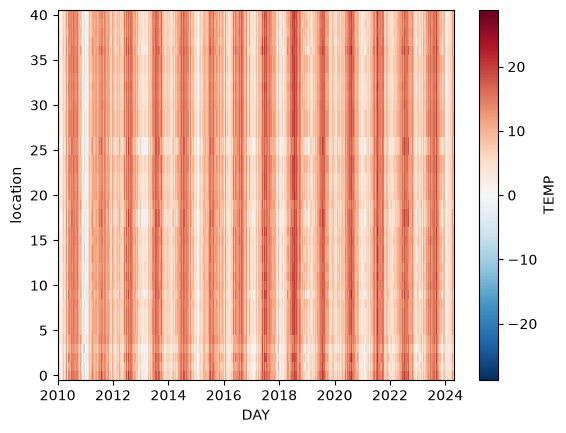

In [8]:
weather_data["TEMP"].plot.imshow()

In order to feed weather data to diffWOFOST, we create a genetor object that iterates over the time axis:

In [9]:
weather_data_gen = to_weather_data_iterator(weather_data[["LAT", "TEMP"]])

We now define the other required elements to run a simulation, i.e. the parameters, the model configuration, and (an almost empty) agromanagement:

In [10]:
def set_up_params(dos):
    """Set up parameter dictionary, including dates of sowing."""
    crop_data_provider = YAMLCropDataProvider()
    crop_data = crop_data_provider._store["barley"]["Spring_barley_301"]
    params = {k: v[0] for k, v in crop_data.items() if k != "Metadata"}
    params.update(CROP_START_TYPE="sowing", CROP_END_TYPE="maturity", CROP_START_DATE=dos)
    return params

In [11]:
# Extract the date of sowing ("DOS") from the observation data
dos = observations.DOS.apply(lambda x: x.toordinal())
params = set_up_params(dos.values)

In [ ]:
model_config = Configuration(
    CROP=DVS_Phenology,
    OUTPUT_VARS=[
        "DVS",
        "STAGE",
        "DOS",  # date of sowing
        "DOA",  # date of anthesis
        "DOM",  # date of maturity
    ],
)

In [13]:
# The simulation spans the range of dates for which we have weather data
start_date, end_date = weather_data.DAY[[0, -1]].dt.date
agromanagement = [{start_date.item(): None}, {end_date.item(): None}]

We can finally setup the engine and run the phenology simulation for all locations in one execution:

In [14]:
engine = Engine(config=model_config)
engine.setup(
    parameterprovider=params,
    weatherdataprovider=weather_data_gen,
    agromanagement=agromanagement,
)

In [15]:
%%time
engine.run_till_terminate()

CPU times: user 5.41 s, sys: 31.9 ms, total: 5.44 s
Wall time: 5.46 s


In [16]:
out = engine.get_output()

Let's visualized the output. First DVS vs simulation day, using different colors for the different locations:

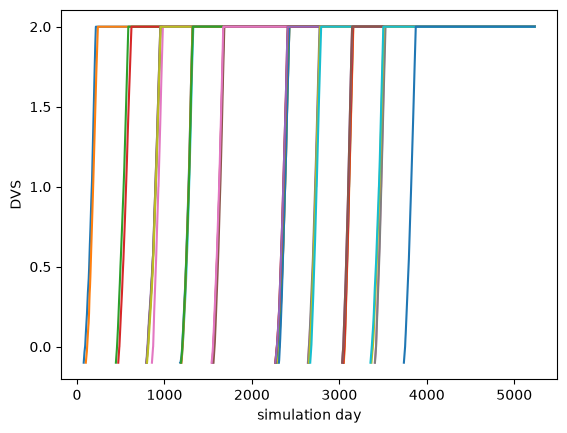

In [17]:
dvs = torch.stack([el["DVS"] for el in out])
plt.plot(dvs)
plt.ylabel("DVS")
plt.xlabel("simulation day") ;

We can plot the same quantity but using the number of days after sowing as x axis. Let's also mask out the DVS values after maturity is reached: 

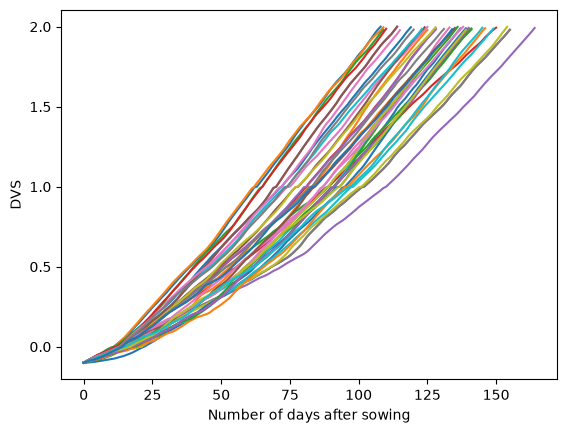

In [ ]:
# DOS and DOM are "historical" markers, we extract them from the last step
dos = out[-1]["DOS"]
dom = out[-1]["DOM"]

days_ordinal = torch.tensor([el["day"].toordinal() for el in out])[:, None]
ndays_from_sowing = days_ordinal - dos
is_not_mature = days_ordinal < dom

plt.plot(ndays_from_sowing, dvs.where(is_not_mature, torch.nan))
plt.ylabel("DVS")
plt.xlabel("Number of days after sowing") ;